# Logdet Method Profiling Across Matrix Sizes

This notebook profiles the runtime of different log-determinant strategies used in bayespecon.

The profiling matrices come from a regular polygon grid generated by the `bayespecon.dgp` module. Each size `n` is a grid side length producing an `n × n` rook-contiguity layout with `n²` spatial units; the spatial graph is built from the polygon GeoDataFrame returned by the DGP function.

Methods compared. We restrict the sweep to methods that are actually viable choices in practice. `exact`, `grid_dense`, and `grid_mc` are omitted because they are dominated on cost, accuracy, or both.

**Deterministic, exact**

- `eigenvalue`: precompute eigenvalues of `W` once; evaluate `sum(log(1 - rho * lam_i))` per call.

**Grid + interpolation (deterministic)**

- `grid_sparse`: exact sparse LU evaluated directly on the grid.
- `sparse_spline`: sparse LU on a grid plus cubic-spline interpolation.
- `grid_ilu`: incomplete-LU (drop-tolerance) factorization on the grid.

**Polynomial / spectral approximation**

- `chebyshev`: Chebyshev polynomial approximation via Clenshaw recurrence (Pace & LeSage 2004).

**Stochastic trace estimators for Chebyshev coefficients**

These are not separate `logdet_method` values. They are selected with `trace_estimator` while keeping `logdet_method="chebyshev"`:

- `trace_estimator="hutchinson"`: plain Hutchinson Monte Carlo trace estimator.
- `trace_estimator="hutchpp"`: Hutch++ variance-reduced trace estimator.
- `trace_estimator="xtrace"`: XTrace leave-one-out variance-reduced trace estimator.

For each matrix size, we report:

- **setup time**: build + compile callable logdet function
- **evaluation time**: average cost to evaluate at many rho values

In [1]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor
import pytensor.tensor as pt
import scipy.sparse as sp
from libpysal import graph

from bayespecon import dgp
from bayespecon.logdet import make_logdet_fn

In [2]:
def make_grid_w(n_side: int) -> np.ndarray:
    """Create a row-standardized rook-contiguity matrix from an n_side x n_side polygon grid.

    Uses ``dgp.simulate_sar`` with ``create_gdf=True`` to generate the polygon
    geometry, then builds a contiguity graph from the returned GeoDataFrame.
    """
    gdf = dgp.simulate_sar(n=n_side, create_gdf=True)
    W = (
        graph.Graph.build_contiguity(gdf, rook=True)
        .transform("r")
        .sparse.toarray()
        .astype(np.float64)
    )
    return W


def compile_logdet_callable(
    W: np.ndarray,
    method: str,
    rho_min: float,
    rho_max: float,
    trace_estimator: str | None = None,
    trace_k: int | None = None,
):
    """Return a compiled callable f(rho) and its setup time in seconds."""
    trace_kwargs = {}
    if trace_estimator is not None:
        trace_kwargs["trace_estimator"] = trace_estimator
    if trace_k is not None:
        trace_kwargs["trace_k"] = trace_k

    t0 = time.perf_counter()
    rho = pt.scalar("rho")
    expr = make_logdet_fn(
        W,
        method=method,
        rho_min=rho_min,
        rho_max=rho_max,
        **trace_kwargs,
    )(rho)
    fn = pytensor.function([rho], expr)
    setup_s = time.perf_counter() - t0
    return fn, setup_s


def bench_eval_seconds(fn, rhos: np.ndarray, repeats: int = 5) -> float:
    """Median per-call evaluation latency in microseconds."""
    run_times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        for r in rhos:
            _ = fn(float(r))
        elapsed = time.perf_counter() - t0
        run_times.append(elapsed / len(rhos))
    return float(np.median(run_times))

In [3]:
@dataclass
class ProfileConfig:
    # Grid side lengths; obs count = n_side². e.g. 10→100, 20→400, 75→5625.
    sizes: tuple[int, ...] = (10, 20, 25, 40, 50, 75)
    method_specs: tuple[dict, ...] = (
        {"label": "eigenvalue", "method": "eigenvalue", "rho_min": -0.95, "rho_max": 0.95},
        {"label": "grid_sparse", "method": "grid_sparse", "rho_min": -0.95, "rho_max": 0.95},
        {"label": "sparse_spline", "method": "sparse_spline", "rho_min": 1e-5, "rho_max": 0.95},
        {"label": "grid_ilu", "method": "grid_ilu", "rho_min": -0.95, "rho_max": 0.95},
        {"label": "chebyshev", "method": "chebyshev", "rho_min": -0.95, "rho_max": 0.95},
        {
            "label": "chebyshev+hutchinson",
            "method": "chebyshev",
            "trace_estimator": "hutchinson",
            "rho_min": -0.95,
            "rho_max": 0.95,
        },
        {
            "label": "chebyshev+hutchpp",
            "method": "chebyshev",
            "trace_estimator": "hutchpp",
            "rho_min": -0.95,
            "rho_max": 0.95,
        },
        {
            "label": "chebyshev+xtrace",
            "method": "chebyshev",
            "trace_estimator": "xtrace",
            "rho_min": -0.95,
            "rho_max": 0.95,
        },
    )
    method_max_n: dict = None
    eval_points: int = 80
    eval_repeats: int = 3
    seed: int = 2026

    def __post_init__(self):
        if self.method_max_n is None:
            self.method_max_n = {spec["label"]: 75 for spec in self.method_specs}


cfg = ProfileConfig()

results = []
skipped = []

for n in cfg.sizes:
    W = make_grid_w(n_side=n)
    print(f"Profiling n_side={n} ({n * n} obs)...")
    for spec in cfg.method_specs:
        label = spec["label"]
        method = spec["method"]
        trace_estimator = spec.get("trace_estimator")
        trace_k = spec.get("trace_k")

        if n > cfg.method_max_n[label]:
            skipped.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": label,
                    "reason": "above method_max_n cap",
                }
            )
            continue

        rho_min = spec["rho_min"]
        rho_max = spec["rho_max"]
        rho_grid = np.linspace(rho_min, rho_max, cfg.eval_points)

        try:
            fn, setup_s = compile_logdet_callable(
                W,
                method=method,
                rho_min=rho_min,
                rho_max=rho_max,
                trace_estimator=trace_estimator,
                trace_k=trace_k,
            )
            eval_s = bench_eval_seconds(fn, rho_grid, repeats=cfg.eval_repeats)
            results.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": label,
                    "logdet_method": method,
                    "trace_estimator": trace_estimator or "",
                    "trace_k": trace_k,
                    "rho_min": rho_min,
                    "rho_max": rho_max,
                    "setup_ms": 1e3 * setup_s,
                    "eval_us": 1e6 * eval_s,
                }
            )
        except Exception as exc:
            skipped.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": label,
                    "reason": f"failed: {type(exc).__name__}: {exc}",
                }
            )

res = pd.DataFrame(results).sort_values(["method", "n_obs"]).reset_index(drop=True)
if not res.empty:
    res["total_ms"] = res["setup_ms"] + (res["eval_us"] * cfg.eval_points / 1e3)

res

Profiling n_side=10 (100 obs)...
Profiling n_side=20 (400 obs)...
Profiling n_side=25 (625 obs)...
Profiling n_side=40 (1600 obs)...
Profiling n_side=50 (2500 obs)...
Profiling n_side=75 (5625 obs)...


,n_side,n_obs,method,logdet_method,trace_estimator,trace_k,rho_min,rho_max,setup_ms,eval_us,total_ms
0,10,100,chebyshev,chebyshev,,None,-0.95000,0.95,78.364541,2.559887,78.569332
1,20,400,chebyshev,chebyshev,,None,-0.95000,0.95,83.686458,2.225512,83.864499
2,25,625,chebyshev,chebyshev,,None,-0.95000,0.95,121.749292,2.130200,121.919708
3,40,1600,chebyshev,chebyshev,,None,-0.95000,0.95,450.257875,2.216663,450.435208
4,50,2500,chebyshev,chebyshev,,None,-0.95000,0.95,581.411292,2.170838,581.584959
5,75,5625,chebyshev,chebyshev,,None,-0.95000,0.95,618.913500,2.129163,619.083833
6,10,100,chebyshev+hutchinson,chebyshev,hutchinson,None,-0.95000,0.95,69.858000,2.187500,70.033000
7,20,400,chebyshev+hutchinson,chebyshev,hutchinson,None,-0.95000,0.95,77.253541,2.130212,77.423958
8,25,625,chebyshev+hutchinson,chebyshev,hutchinson,None,-0.95000,0.95,115.296375,2.518750,115.497875
9,40,1600,chebyshev+hutchinson,chebyshev,hutchinson,None,-0.95000,0.95,440.910750,2.236976,441.089708


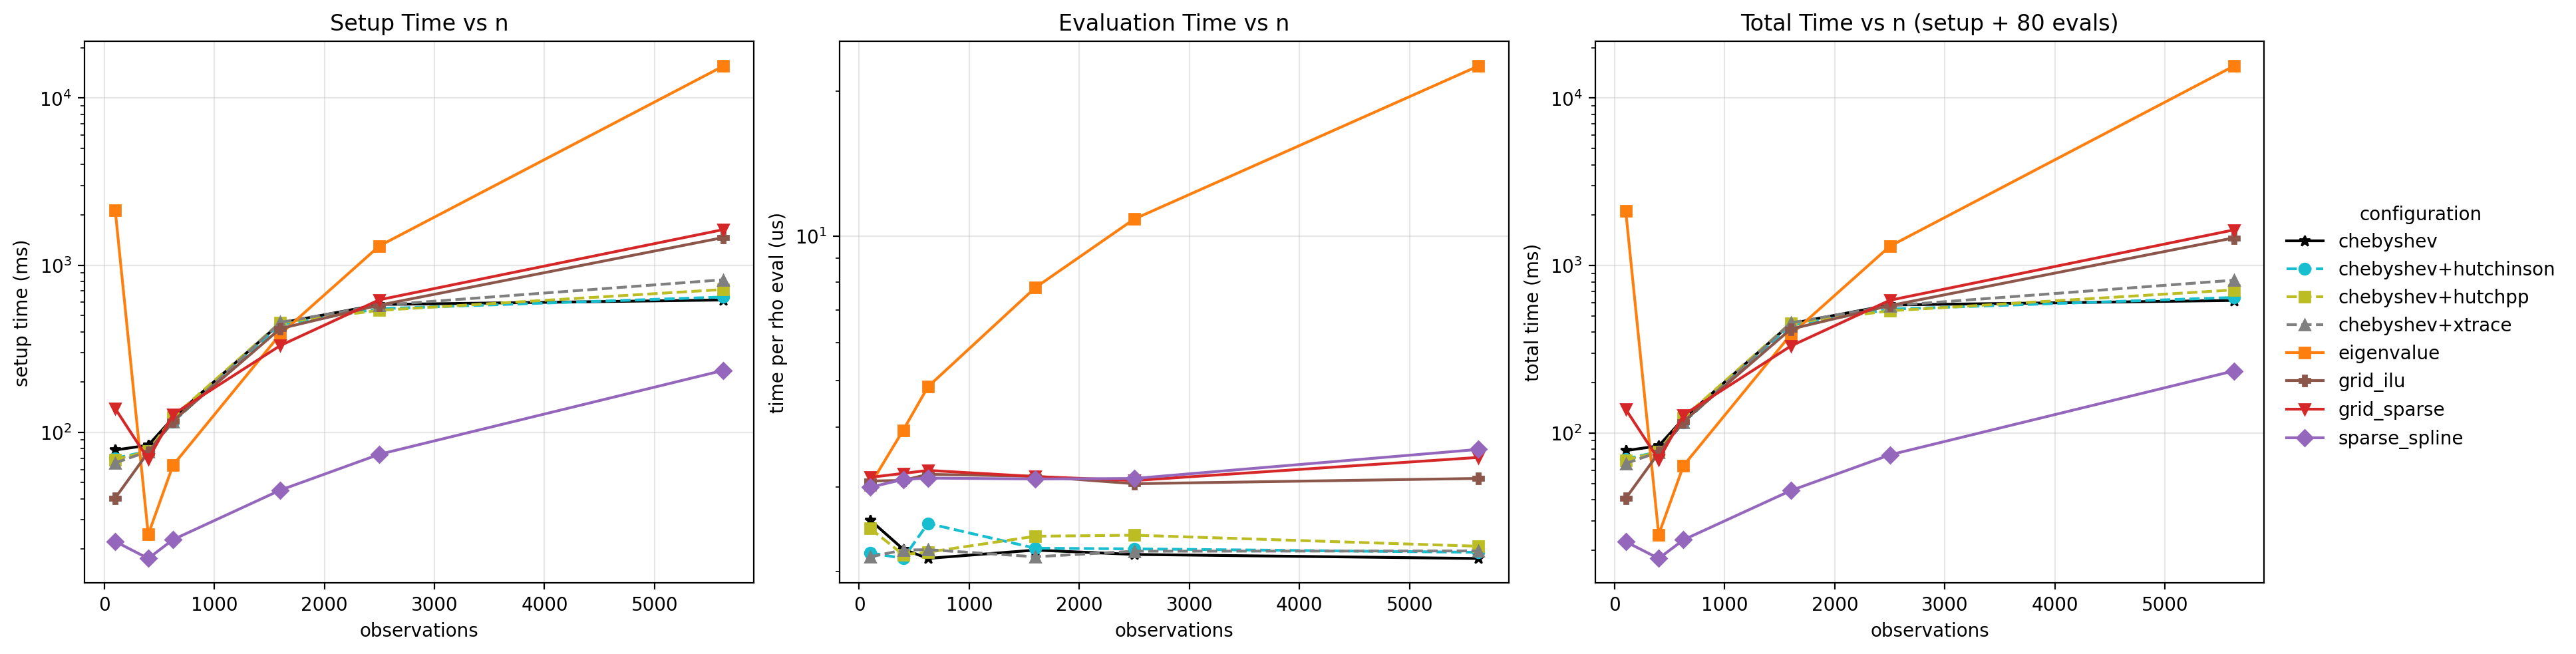

In [4]:
if res.empty:
    raise RuntimeError("No profiling results were generated.")

# Distinct color + marker per profiled configuration.
method_styles = {
    "eigenvalue":              {"color": "#ff7f0e", "marker": "s", "linestyle": "-"},
    "grid_sparse":             {"color": "#d62728", "marker": "v", "linestyle": "-"},
    "sparse_spline":           {"color": "#9467bd", "marker": "D", "linestyle": "-"},
    "grid_ilu":                {"color": "#8c564b", "marker": "P", "linestyle": "-"},
    "chebyshev":               {"color": "#000000", "marker": "*", "linestyle": "-"},
    "chebyshev+hutchinson":    {"color": "#17becf", "marker": "o", "linestyle": "--"},
    "chebyshev+hutchpp":       {"color": "#bcbd22", "marker": "s", "linestyle": "--"},
    "chebyshev+xtrace":        {"color": "#7f7f7f", "marker": "^", "linestyle": "--"},
}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)

for method, grp in res.groupby("method"):
    grp = grp.sort_values("n_obs")
    style = method_styles.get(method, {"marker": "o"})
    axes[0].plot(grp["n_obs"], grp["setup_ms"], label=method, **style)
    axes[1].plot(grp["n_obs"], grp["eval_us"], label=method, **style)
    axes[2].plot(grp["n_obs"], grp["total_ms"], label=method, **style)

axes[0].set_title("Setup Time vs n")
axes[0].set_xlabel("observations")
axes[0].set_ylabel("setup time (ms)")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Evaluation Time vs n")
axes[1].set_xlabel("observations")
axes[1].set_ylabel("time per rho eval (us)")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

axes[2].set_title(f"Total Time vs n (setup + {cfg.eval_points} evals)")
axes[2].set_xlabel("observations")
axes[2].set_ylabel("total time (ms)")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

# Single shared legend to the right of the figure so it doesn't crowd the panels.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
    title="configuration",
)

plt.show()

In [5]:
summary = res.pivot_table(
    index="n_obs", columns="method", values=["setup_ms", "eval_us", "total_ms"]
).sort_index()
display(summary)

if skipped:
    skipped_df = (
        pd.DataFrame(skipped).sort_values(["n_side", "method"]).reset_index(drop=True)
    )
    print("Skipped combinations (due to safety caps or failures):")
    display(skipped_df)

eval_us                                                          \
method chebyshev chebyshev+hutchinson chebyshev+hutchpp chebyshev+xtrace   
n_obs                                                                      
100     2.559887             2.187500          2.458863         2.145837   
400     2.225512             2.130212          2.168750         2.217187   
625     2.130200             2.518750          2.194800         2.221350   
1600    2.216663             2.236976          2.368751         2.146875   
2500    2.170838             2.229687          2.380737         2.204688   
5625    2.129163             2.193237          2.257813         2.207812   

                                                         setup_ms  \
method eigenvalue  grid_ilu grid_sparse sparse_spline   chebyshev   
n_obs                                                               
100      3.030213  3.086450    3.142188      2.995825   78.364541   
400      3.939062  3.096350    3.201563      3.110425   83.686458   
625      4.850525  3.188013    3.248437      3.130725  121.749292   
1600     7.801050  3.157812    3.154163      3.117187  450.257875   
2500    10.843225  3.047400    3.094275      3.125000  581.411292   
5625    22.569800  3.125525    3.456775      3.592188  618.913500   

                             ...                               total_ms  \
method chebyshev+hutchinson  ...  grid_sparse sparse_spline   chebyshev   
n_obs                        ...                                          
100               69.858000  ...   138.618125     22.223250   78.569332   
400               77.253541  ...    69.006000     17.586125   83.864499   
625              115.296375  ...   127.957750     22.801667  121.919708   
1600             440.910750  ...   330.460292     45.092458  450.435208   
2500             548.966583  ...   620.468667     73.859750  581.584959   
5625             644.649250  ...  1631.796083    234.649125  619.083833   

                                                                              \
method chebyshev+hutchinson chebyshev+hutchpp chebyshev+xtrace    eigenvalue   
n_obs                                                                          
100               70.033000         68.924250        65.794375   2128.481334   
400               77.423958         77.049459        76.997208     24.773458   
625              115.497875        123.718168       115.769416     63.914292   
1600             441.089708        453.922959       455.171667    387.183876   
2500             549.144958        536.673125       575.427417   1303.887833   
5625             644.824709        715.126833       817.572458  15515.159292   

                                                
method     grid_ilu  grid_sparse sparse_spline  
n_obs                                           
100       40.706208   138.869500     22.462916  
400       76.305416    69.262125     17.834959  
625      117.229708   128.217625     23.052125  
1600     417.511958   330.712625     45.341833  
2500     576.764458   620.716209     74.109750  
5625    1463.003000  1632.072625    234.936500  

[6 rows x 24 columns]

## Logdet Approximation Accuracy

This section directly compares how accurately each stochastic method approximates the true log-determinant curve, independent of sampling noise. We compute the exact log|I - ρW| via eigenvalues and compare against each method's approximation across a dense ρ grid.


,method,logdet_method,trace_estimator,max_err,mean_err,rmse
0,chebyshev+hutchinson,chebyshev,hutchinson,0.004307,0.000746,0.001017
1,chebyshev+hutchpp,chebyshev,hutchpp,0.004307,0.000746,0.001017
2,chebyshev+xtrace,chebyshev,xtrace,0.004307,0.000746,0.001017


/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


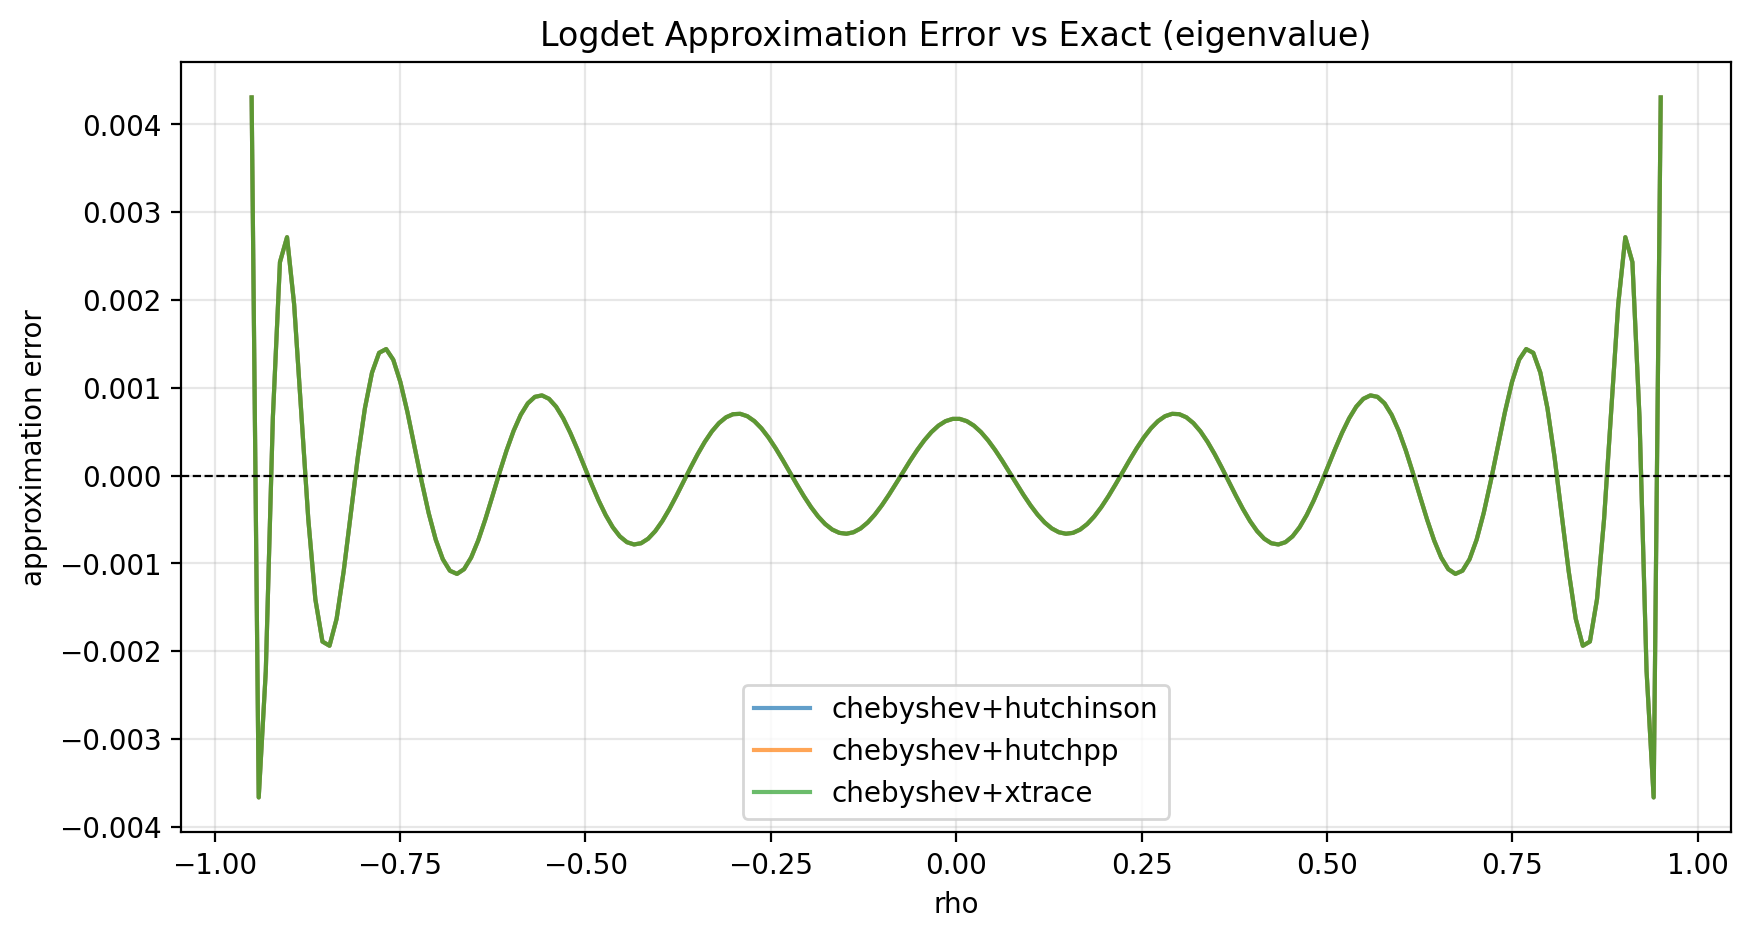

In [6]:
from bayespecon.logdet import make_logdet_numpy_fn

# Use the same W from the last profiling run (or regenerate)
W_accuracy = make_grid_w(n_side=25)
W_sp = sp.csr_matrix(W_accuracy)

# Exact logdet via eigenvalues
W_dense = W_sp.toarray()
eigs = np.linalg.eigvals(W_dense)
rho_grid_acc = np.linspace(-0.95, 0.95, 200)
exact_logdet = np.array([np.sum(np.log(1 - r * eigs)) for r in rho_grid_acc])

trace_configs = {
    "chebyshev+hutchinson": "hutchinson",
    "chebyshev+hutchpp": "hutchpp",
    "chebyshev+xtrace": "xtrace",
}

acc_rows = []
for name, estimator in trace_configs.items():
    fn = make_logdet_numpy_fn(
        W_sp,
        None,
        method="chebyshev",
        rho_min=-0.95,
        rho_max=0.95,
        trace_estimator=estimator,
    )
    approx = np.array([fn(r) for r in rho_grid_acc])
    err = np.abs(approx - exact_logdet)
    acc_rows.append(
        {
            "method": name,
            "logdet_method": "chebyshev",
            "trace_estimator": estimator,
            "max_err": err.max(),
            "mean_err": err.mean(),
            "rmse": np.sqrt((err**2).mean()),
        }
    )

acc_df = pd.DataFrame(acc_rows).sort_values("rmse").reset_index(drop=True)
display(acc_df)

fig, ax = plt.subplots(figsize=(10, 5))
for name, estimator in trace_configs.items():
    fn = make_logdet_numpy_fn(
        W_sp,
        None,
        method="chebyshev",
        rho_min=-0.95,
        rho_max=0.95,
        trace_estimator=estimator,
    )
    approx = np.array([fn(r) for r in rho_grid_acc])
    ax.plot(rho_grid_acc, approx - exact_logdet, label=name, alpha=0.7)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("rho")
ax.set_ylabel("approximation error")
ax.set_title("Logdet Approximation Error vs Exact (eigenvalue)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Coefficient and Fit-Time Comparison Across Logdet Methods

This section uses a regular polygon grid generated by `bayespecon.dgp` to simulate one SAR dataset, maps the simulated response, and estimates the same SAR model using each `logdet_method`.

We compare:

- posterior mean coefficients (`rho`, `beta_0`, `beta_1`, `beta_2`)
- total wall-clock time to estimate each model

To keep this section runnable in docs contexts, sampling is intentionally modest.


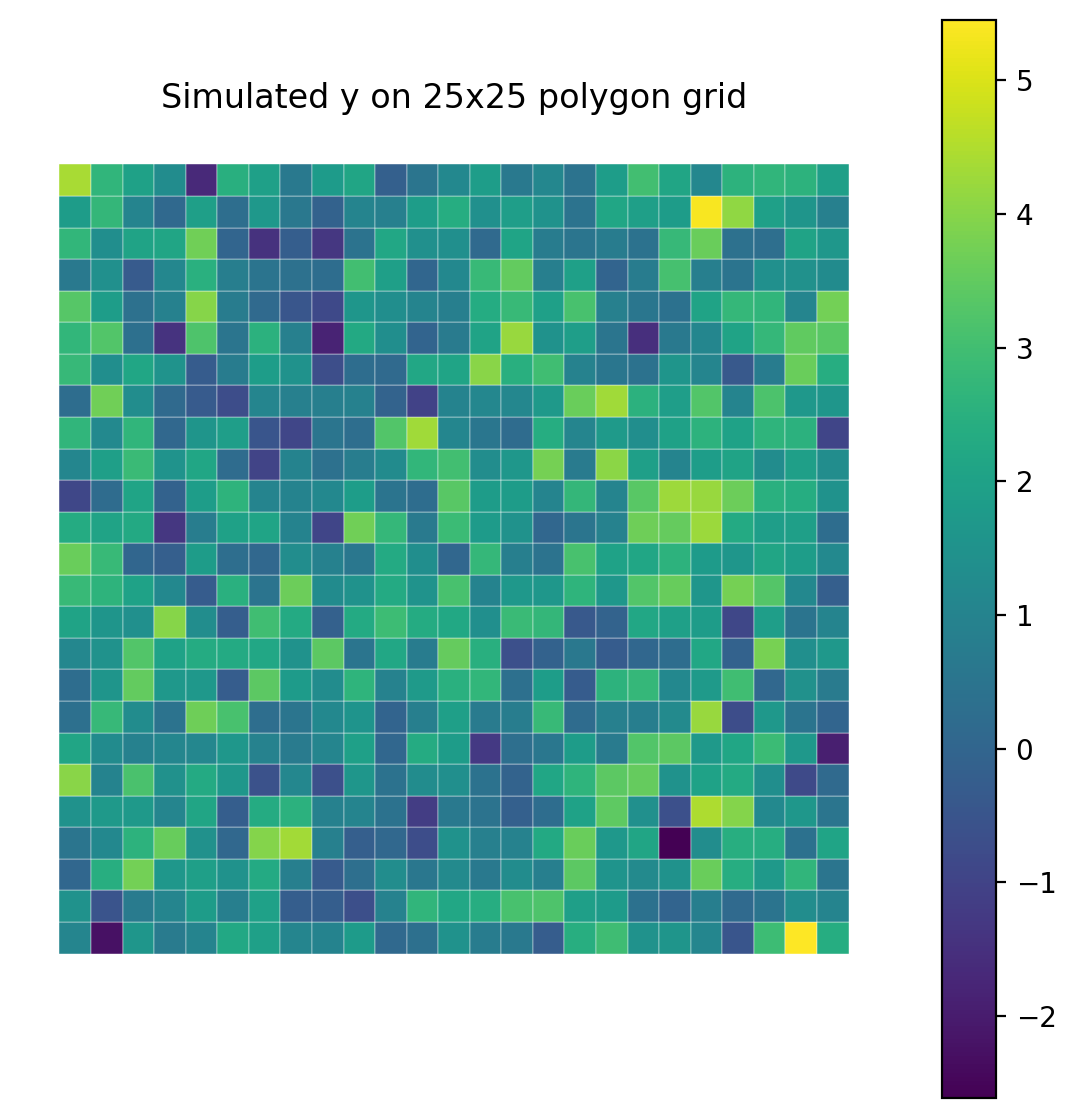

Estimating SAR with eigenvalue...
Estimating SAR with chebyshev...
Estimating SAR with chebyshev+hutchinson...
Estimating SAR with chebyshev+hutchpp...
Estimating SAR with chebyshev+xtrace...


,method,logdet_method,trace_estimator,trace_k,total_time_s,rho,beta_0,beta_1,beta_2,rho_true,...,beta_0_true,abs_err_beta_0,beta_1_true,abs_err_beta_1,beta_2_true,abs_err_beta_2,delta_vs_eigen_rho,delta_vs_eigen_beta_0,delta_vs_eigen_beta_1,delta_vs_eigen_beta_2
0,chebyshev,chebyshev,,None,1.751278,0.379084,0.886479,0.810998,-0.519154,0.35,...,1.0,0.113521,0.8,0.010998,-0.5,0.019154,-0.002527,0.003286,0.000508,-0.000207
1,chebyshev+hutchpp,chebyshev,hutchpp,None,1.770295,0.379084,0.886479,0.810998,-0.519154,0.35,...,1.0,0.113521,0.8,0.010998,-0.5,0.019154,-0.002527,0.003286,0.000508,-0.000207
2,chebyshev+hutchinson,chebyshev,hutchinson,None,1.798679,0.379084,0.886479,0.810998,-0.519154,0.35,...,1.0,0.113521,0.8,0.010998,-0.5,0.019154,-0.002527,0.003286,0.000508,-0.000207
3,chebyshev+xtrace,chebyshev,xtrace,None,1.859244,0.379084,0.886479,0.810998,-0.519154,0.35,...,1.0,0.113521,0.8,0.010998,-0.5,0.019154,-0.002527,0.003286,0.000508,-0.000207
4,eigenvalue,eigenvalue,,None,2.063844,0.381611,0.883193,0.810490,-0.518948,0.35,...,1.0,0.116807,0.8,0.010490,-0.5,0.018948,0.000000,0.000000,0.000000,0.000000


In [7]:
from bayespecon import SAR


def simulate_sar_data(n_side: int = 25, seed: int = 2026):
    """Simulate SAR data on an n_side x n_side polygon grid using the DGP module."""
    rng = np.random.default_rng(seed)
    beta_true = np.array([1.0, 0.8, -0.5], dtype=np.float64)
    rho_true = 0.35
    sigma_true = 0.7

    gdf = dgp.simulate_sar(
        n=n_side,
        rho=rho_true,
        beta=beta_true,
        sigma=sigma_true,
        rng=rng,
        create_gdf=True,
    )
    # Keep the SAR parameterization consistent with model assumptions.
    W_graph = graph.Graph.build_contiguity(gdf, rook=True).transform("r")
    y = gdf["y"].to_numpy()
    X_cols = [c for c in gdf.columns if c.startswith("X_")]
    X = gdf[X_cols].to_numpy()
    return gdf, y, X, W_graph, rho_true, beta_true


def fit_sar_for_method(
    y,
    X,
    W,
    method: str,
    label: str | None = None,
    trace_estimator: str | None = None,
    trace_k: int | None = None,
    draws: int = 1000,
    tune: int = 1000,
    seed: int = 2026,
):
    """Fit SAR with a specific logdet configuration and return posterior means + runtime."""
    trace_kwargs = {}
    if trace_estimator is not None:
        trace_kwargs["trace_estimator"] = trace_estimator
    if trace_k is not None:
        trace_kwargs["trace_k"] = trace_k

    t0 = time.perf_counter()

    model = SAR(
        y=y,
        X=X,
        W=W,
        logdet_method=method,
        **trace_kwargs,
    )
    idata = model.fit(
        draws=draws,
        tune=tune,
        chains=2,
        cores=1,
        random_seed=seed,
        target_accept=0.95,
        progressbar=False,
        compute_convergence_checks=False,
    )

    elapsed_s = time.perf_counter() - t0
    beta_mean = idata.posterior["beta"].mean(("chain", "draw")).to_numpy()
    rho_mean = float(idata.posterior["rho"].mean(("chain", "draw")).to_numpy())

    return {
        "method": label or method,
        "logdet_method": method,
        "trace_estimator": trace_estimator or "",
        "trace_k": trace_k,
        "total_time_s": elapsed_s,
        "rho": rho_mean,
        "beta_0": float(beta_mean[0]),
        "beta_1": float(beta_mean[1]),
        "beta_2": float(beta_mean[2]),
    }


methods_for_model = [
    {"label": "eigenvalue", "method": "eigenvalue"},
    {"label": "chebyshev", "method": "chebyshev"},
    {"label": "chebyshev+hutchinson", "method": "chebyshev", "trace_estimator": "hutchinson"},
    {"label": "chebyshev+hutchpp", "method": "chebyshev", "trace_estimator": "hutchpp"},
    {"label": "chebyshev+xtrace", "method": "chebyshev", "trace_estimator": "xtrace"},
]
gdf_model, y_model, X_model, W_model, rho_true, beta_true = simulate_sar_data(n_side=25)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
gdf_model.plot(
    column="y", cmap="viridis", legend=True, linewidth=0.15, edgecolor="white", ax=ax
)
ax.set_title("Simulated y on 25x25 polygon grid")
ax.set_axis_off()
plt.show()

model_rows = []
for spec in methods_for_model:
    label = spec["label"]
    print(f"Estimating SAR with {label}...")
    try:
        model_rows.append(
            fit_sar_for_method(
                y_model,
                X_model,
                W_model,
                method=spec["method"],
                label=label,
                trace_estimator=spec.get("trace_estimator"),
                trace_k=spec.get("trace_k"),
            )
        )
    except Exception as exc:
        model_rows.append(
            {
                "method": label,
                "logdet_method": spec["method"],
                "trace_estimator": spec.get("trace_estimator", ""),
                "trace_k": spec.get("trace_k"),
                "total_time_s": np.nan,
                "rho": np.nan,
                "beta_0": np.nan,
                "beta_1": np.nan,
                "beta_2": np.nan,
                "error": f"{type(exc).__name__}: {exc}",
            }
        )

coef_compare = pd.DataFrame(model_rows)
coef_compare = coef_compare.sort_values("total_time_s", na_position="last").reset_index(
    drop=True
)

coef_compare["rho_true"] = rho_true
coef_compare["abs_err_rho"] = (coef_compare["rho"] - rho_true).abs()
for j, btrue in enumerate(beta_true):
    coef_compare[f"beta_{j}_true"] = btrue
    coef_compare[f"abs_err_beta_{j}"] = (coef_compare[f"beta_{j}"] - btrue).abs()

if "eigenvalue" in coef_compare["method"].values:
    base = coef_compare.loc[
        coef_compare["method"] == "eigenvalue", ["rho", "beta_0", "beta_1", "beta_2"]
    ].iloc[0]
    for col in ["rho", "beta_0", "beta_1", "beta_2"]:
        coef_compare[f"delta_vs_eigen_{col}"] = coef_compare[col] - base[col]

coef_compare

## Notes

- `exact` scales as O(n³) per call and is intentionally capped at small n.
- `eigenvalue` carries a one-time O(n³) eigendecomposition cost, then evaluates in O(n) per `rho`. Strong choice for repeated evaluation at moderate n.
- `grid_dense` builds dense LU on a `rho` grid (O(G·n³) setup) and interpolates with a cubic spline; cheap per call but heavy to build at large n.
- `grid_sparse` and `sparse_spline` are sparse-LU variants. `grid_sparse` evaluates the grid directly; `sparse_spline` adds spline interpolation so per-call cost drops to O(1).
- `grid_ilu` swaps the exact sparse LU for an incomplete-LU factorization — fastest sparse setup, with accuracy controlled by the drop tolerance.
- `grid_mc` combines a nonnegative `rho` grid with MC trace evaluation — cheaper setup than the deterministic grid but inherits MC variance.
- `chebyshev` builds Chebyshev coefficients once, then evaluates in O(m) per call. For small matrices or supplied eigenvalues it uses exact spectral coefficients; for large matrices it uses the selected stochastic `trace_estimator`.
- `trace_estimator="hutchinson"` is the cheapest stochastic Chebyshev coefficient builder; `trace_estimator="hutchpp"` uses a low-rank sketch for lower variance; `trace_estimator="xtrace"` uses a leave-one-out correction. All keep `logdet_method="chebyshev"` and support the symmetric `rho` range.
- **Parameter ranges:** `grid_mc` and `sparse_spline` only support nonnegative `rho` and are profiled on `[1e-5, 0.95]`. `chebyshev` and its trace-estimator variants are profiled on the symmetric range `[-0.95, 0.95]`.
- Adjust `ProfileConfig.sizes` and `method_max_n` for deeper stress tests.

,method,logdet_method,trace_estimator,trace_k,ess_rho
0,eigenvalue,eigenvalue,,None,1933.0
1,chebyshev,chebyshev,,None,2136.0
2,chebyshev+hutchinson,chebyshev,hutchinson,None,2136.0
3,chebyshev+hutchpp,chebyshev,hutchpp,None,2136.0
4,chebyshev+xtrace,chebyshev,xtrace,None,2136.0


<Axes: title={'center': 'Effective Sample Size for rho by Logdet Configuration'}, xlabel='method', ylabel='ESS (rho)'>

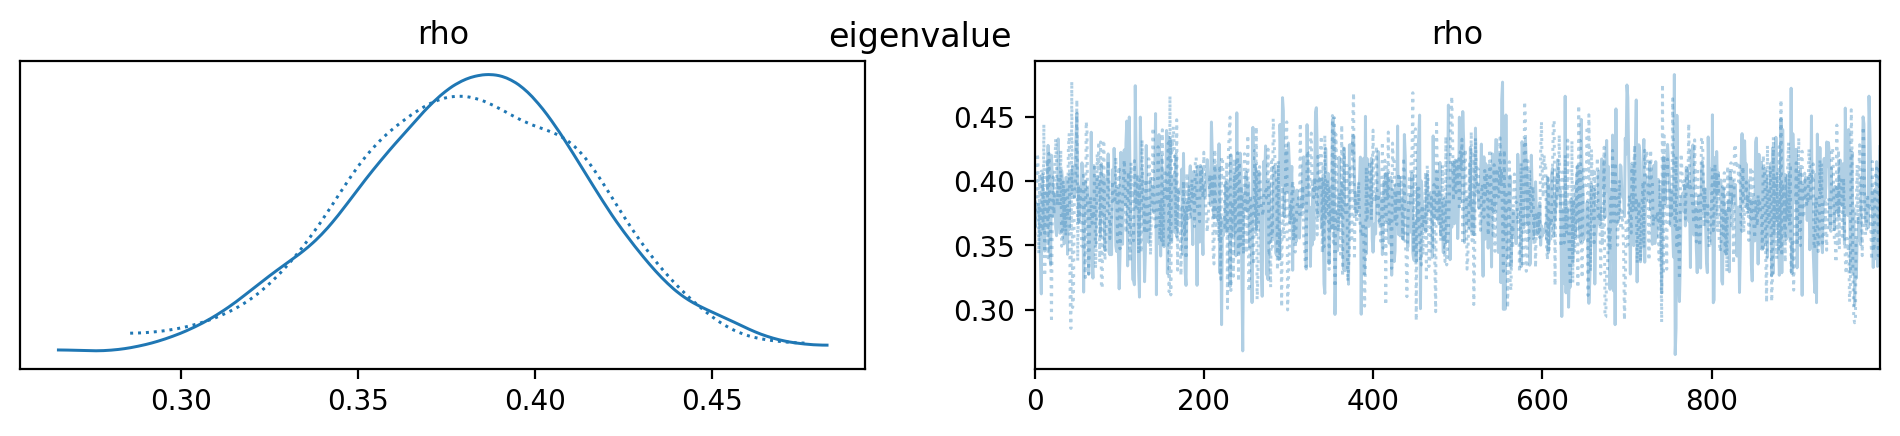

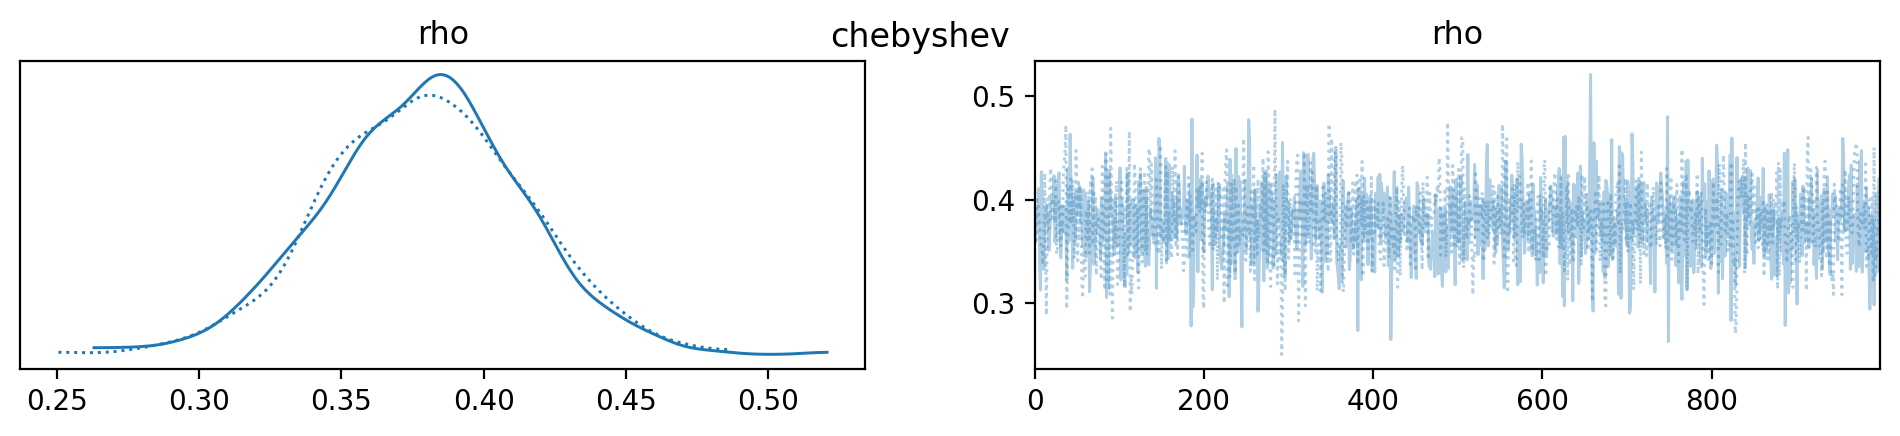

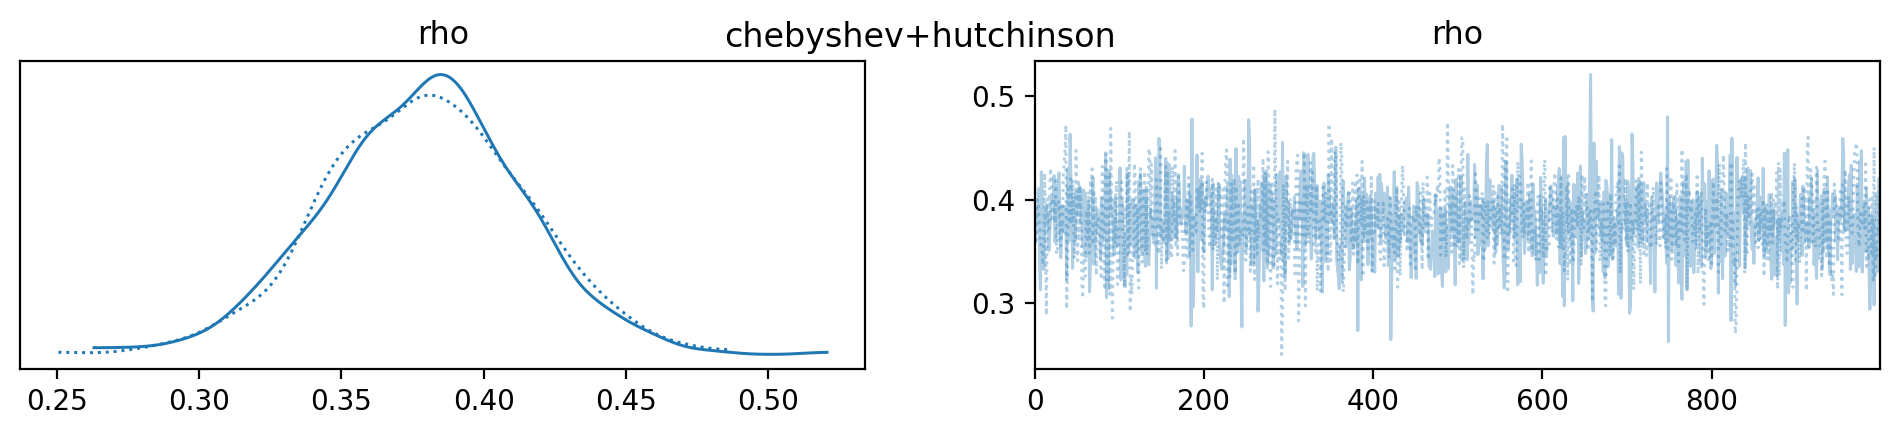

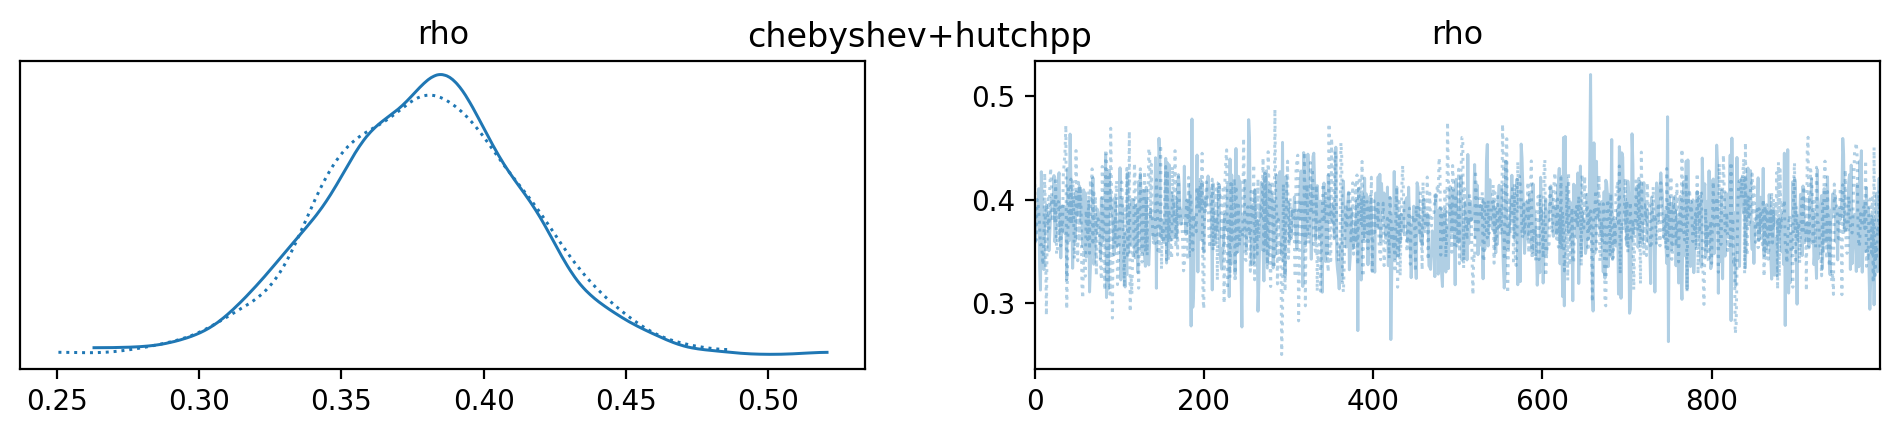

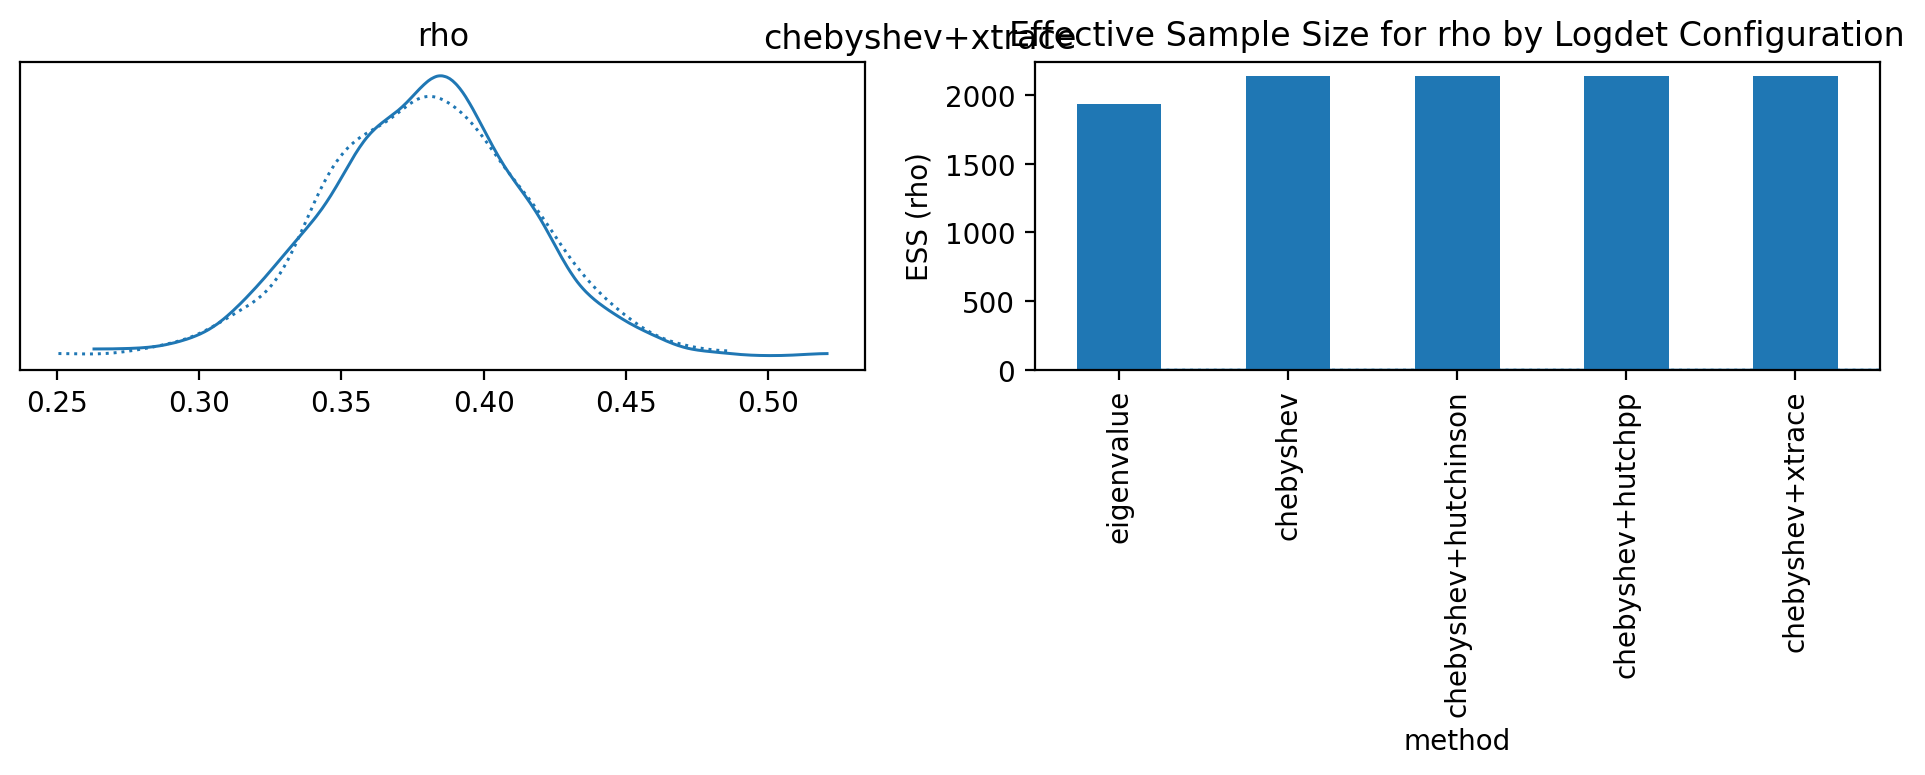

In [8]:
import arviz as az
import pandas as pd

# Refit each logdet configuration and compare effective sample sizes for rho.
ess_rows = []
for spec in methods_for_model:
    label = spec["label"]
    trace_kwargs = {}
    if spec.get("trace_estimator") is not None:
        trace_kwargs["trace_estimator"] = spec["trace_estimator"]
    if spec.get("trace_k") is not None:
        trace_kwargs["trace_k"] = spec["trace_k"]

    model = SAR(
        y=y_model,
        X=X_model,
        W=W_model,
        logdet_method=spec["method"],
        priors={"rho_lower": -1, "rho_upper": 1},
        **trace_kwargs,
    )
    idata = model.fit(
        draws=1000,
        tune=1000,
        chains=2,
        cores=-1,
        random_seed=2026,
        target_accept=0.95,
        progressbar=False,
        compute_convergence_checks=False,
    )
    summary = az.summary(idata, var_names=["rho"])
    ess = summary.loc["rho", "ess_bulk"]
    ess_rows.append(
        {
            "method": label,
            "logdet_method": spec["method"],
            "trace_estimator": spec.get("trace_estimator", ""),
            "trace_k": spec.get("trace_k"),
            "ess_rho": ess,
        }
    )
    az.plot_trace(idata, var_names=["rho"], compact=True, legend=False)
    plt.suptitle(label)

ess_df = pd.DataFrame(ess_rows)
display(ess_df)

ess_df.set_index("method")["ess_rho"].plot.bar(
    ylabel="ESS (rho)", title="Effective Sample Size for rho by Logdet Configuration"
)


## Method selection policy

The auto-selector (`logdet_method=None`) now exposes a single Chebyshev-family public method:

- `eigenvalue` for `n ≤ 500` (exact, fast per-call evaluation)
- `chebyshev` for `n > 500` (cached polynomial approximation evaluated by Clenshaw recurrence)

For large matrices where an eigendecomposition is unavailable, `chebyshev` builds its coefficients from stochastic trace estimates. The estimator is chosen separately with `trace_estimator`:

- default: `trace_estimator="hutchpp"`
- alternatives: `trace_estimator="hutchinson"` or `trace_estimator="xtrace"`
- optional probe count: `trace_k=...`

Why Hutch++ is the default trace estimator: in the profiling sweep it lands on the best cost/accuracy frontier for row-standardized contiguity weights, with much lower build cost than XTrace and lower variance than plain Hutchinson.

Manual overrides:

1. **Default for most work.** Leave `logdet_method=None` and let the auto-selector choose. For large sparse problems this resolves to `chebyshev` with `trace_estimator="hutchpp"`.

2. **Fully deterministic coefficients.** Use `logdet_method="eigenvalue"` when `n` is small enough for the eigendecomposition to be acceptable.

3. **Exploratory trace sweeps.** Use `logdet_method="chebyshev"` with `trace_estimator="hutchinson"`, `"hutchpp"`, or `"xtrace"` and record `trace_k`.

4. **Reporting and publication.** Record `logdet_method`, `trace_estimator`, `trace_k`, and `rho` bounds in every benchmark or model report.